# Augmentation Exploration

This notebook now uses the augmentation helpers from `src/uno_vision/data/augmentations.py`.
It stays focused on previewing transformations and optionally regenerating the processed augmentation dataset.

In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from uno_vision.data.augmentations import (
    crop_image_augmentations,
    generate_augmentations,
    load_aligned_mask,
    load_binary_mask,
    mask_augmentations,
)
from uno_vision.paths import AUGMENTATIONS_DIR, REFERENCE_CARDS_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference cards: {REFERENCE_CARDS_DIR}")
print(f"Augmentations: {AUGMENTATIONS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference cards: C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\processed\reference_cards
Augmentations: C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\processed\augmentations


In [20]:
source_tag = "L1000765"
crop_idx = 0

crop_path = REFERENCE_CARDS_DIR / source_tag / "crops" / f"crop_{crop_idx}.jpg"
mask_dir = REFERENCE_CARDS_DIR / source_tag / "masks"
img_bgr = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read crop: {crop_path}")

mask_fg = load_aligned_mask(mask_dir, crop_idx, img_bgr.shape[0], img_bgr.shape[1])
base_mask = load_binary_mask(mask_dir, crop_idx)
rng = np.random.default_rng(42)

print(f"Crop: {crop_path}")
print(f"Image shape: {img_bgr.shape}")

Crop: C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\processed\reference_cards\L1000765\crops\crop_0.jpg
Image shape: (560, 384, 3)


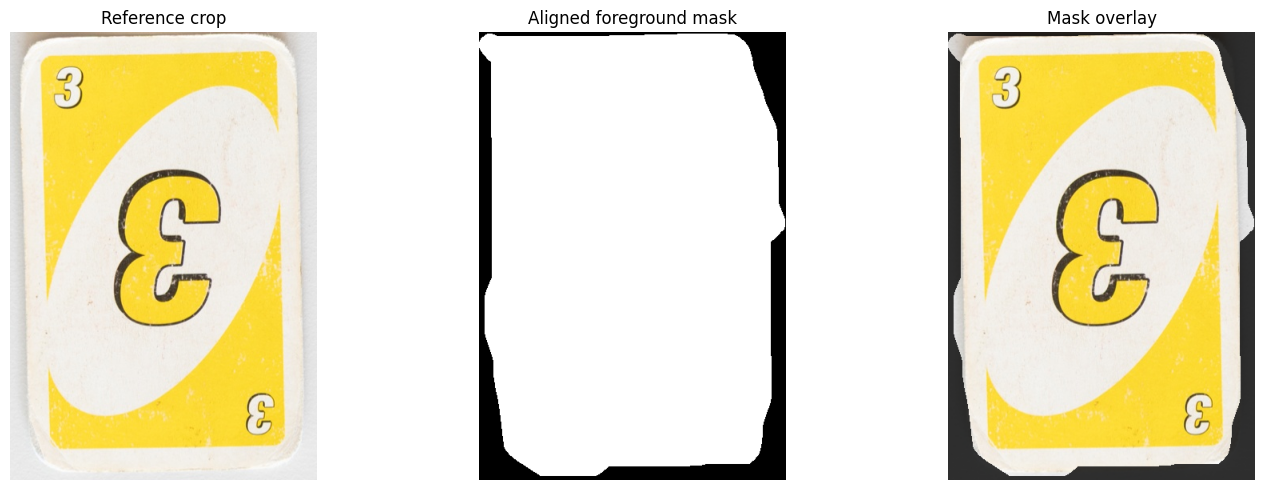

In [21]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[~mask_fg] = (overlay[~mask_fg] * 0.2).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Reference crop")
axes[0].axis("off")

axes[1].imshow(mask_fg, cmap="gray")
axes[1].set_title("Aligned foreground mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

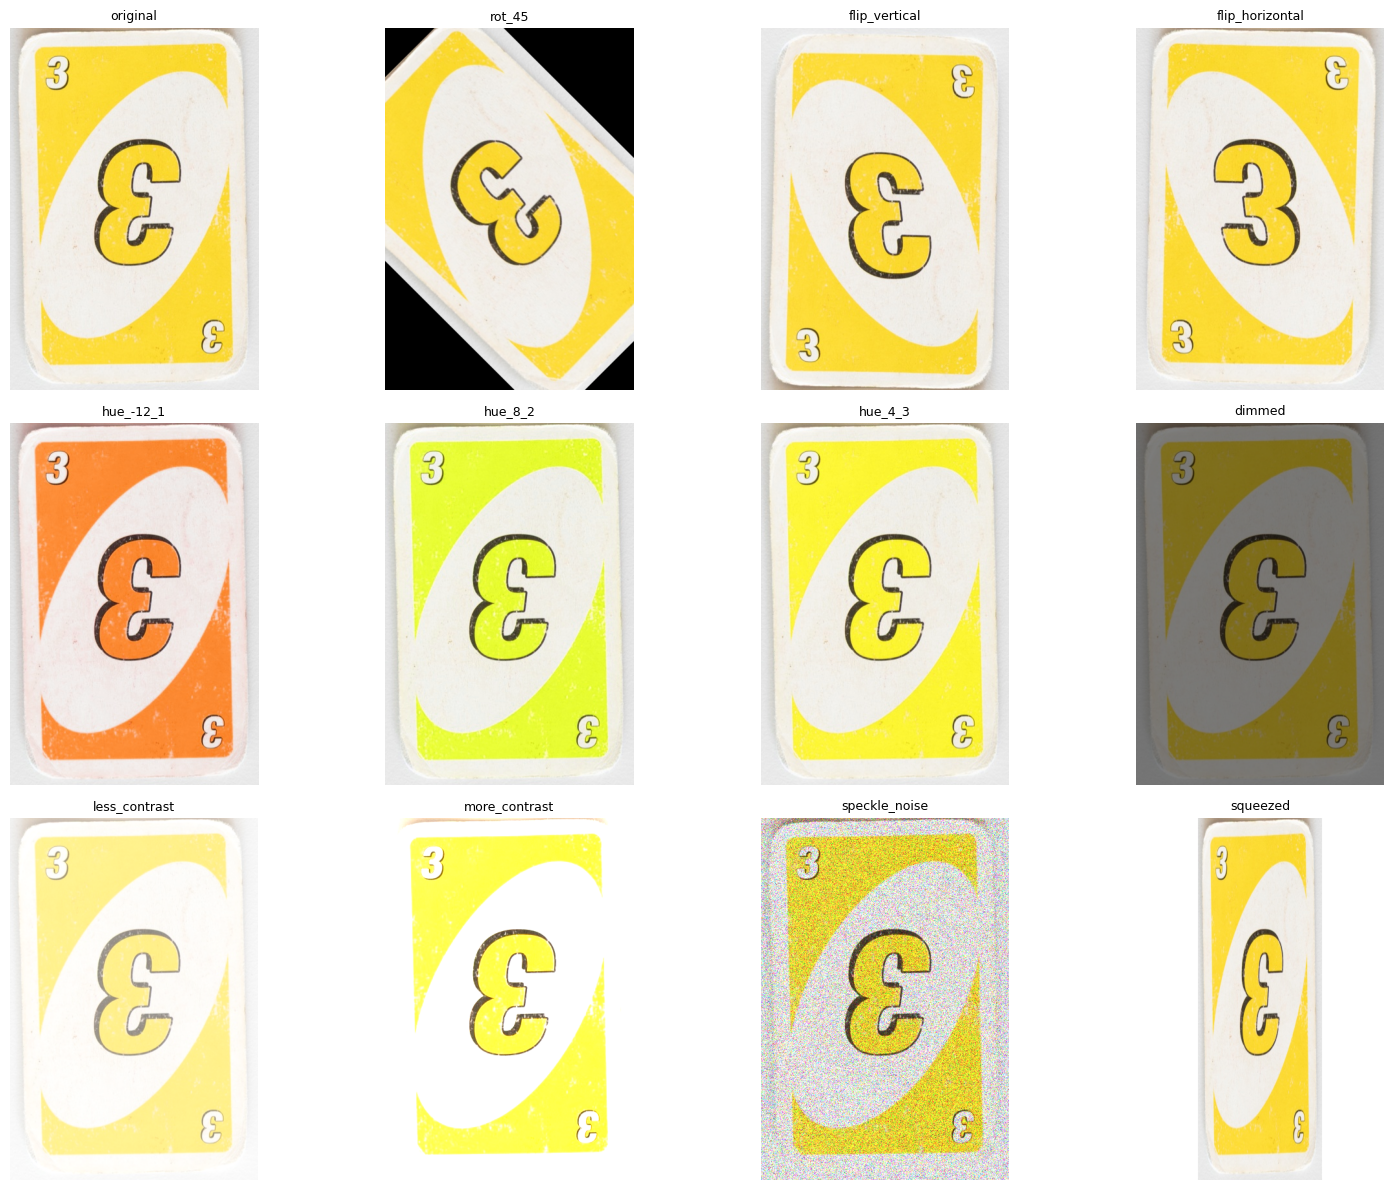

In [22]:
image_augs = [("original", img_bgr)] + crop_image_augmentations(img_bgr, mask_fg, rng)
preview = image_augs[:12]

rows = int(np.ceil(len(preview) / 4))
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, (name, aug_img) in zip(axes, preview):
    ax.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for ax in axes[len(preview):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

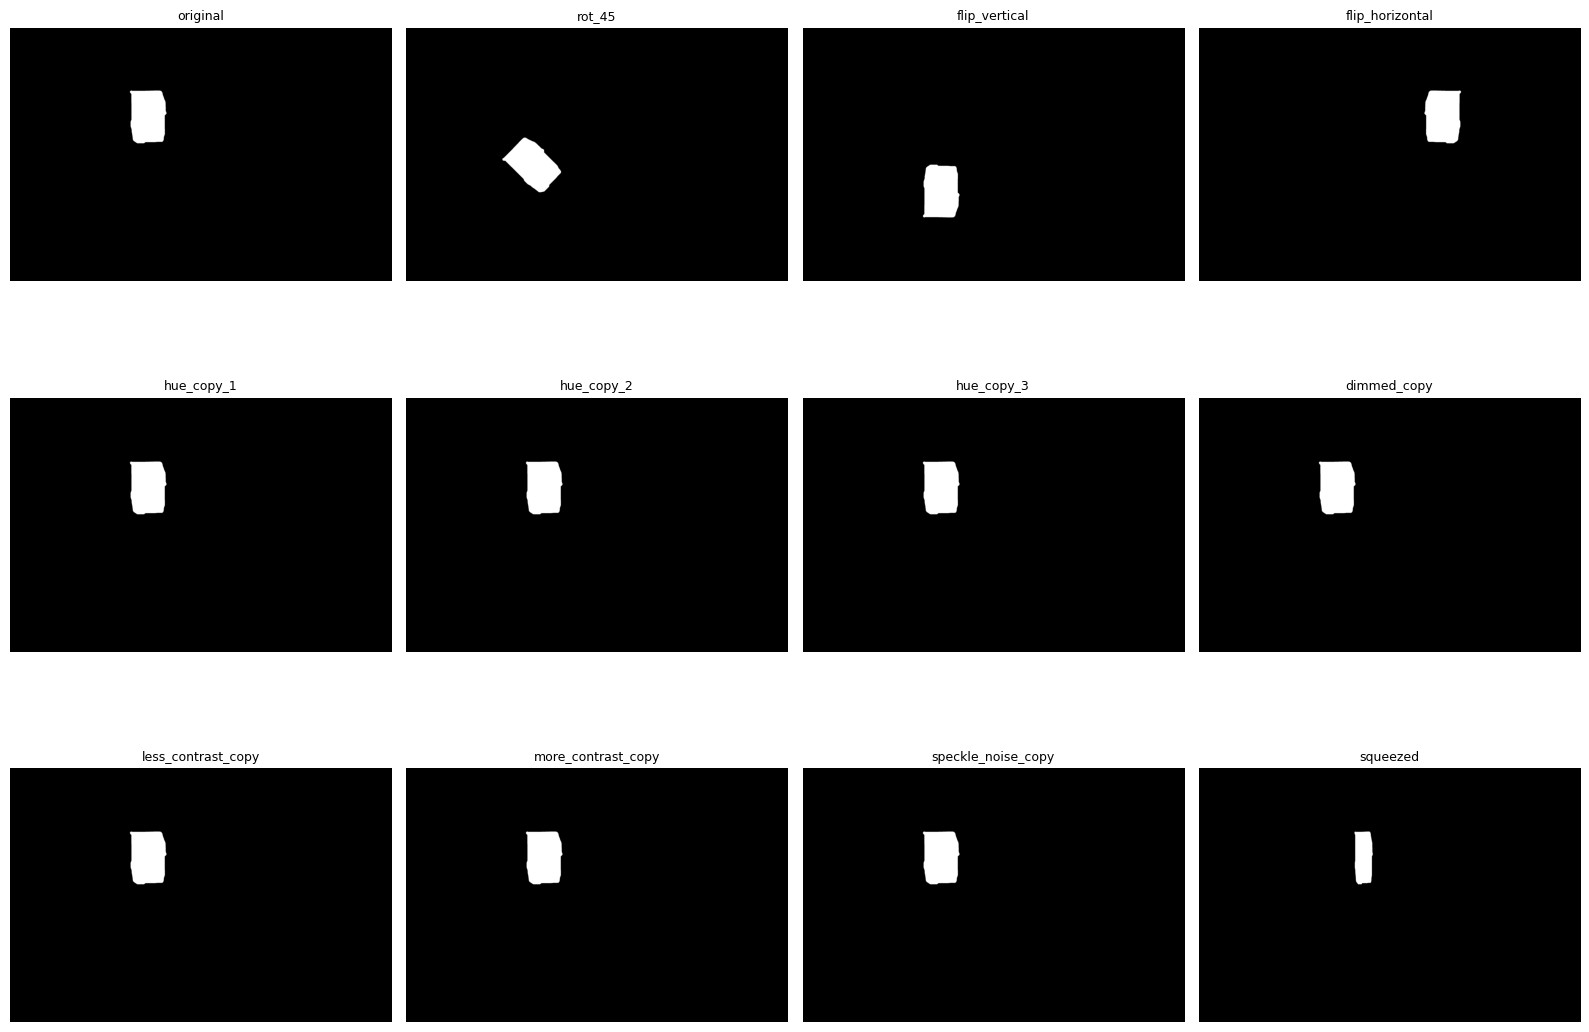

In [23]:
mask_augs = [("original", base_mask)] + mask_augmentations(base_mask, np.random.default_rng(42))
preview = mask_augs[:12]

rows = int(np.ceil(len(preview) / 4))
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, (name, aug_mask) in zip(axes, preview):
    ax.imshow(aug_mask, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for ax in axes[len(preview):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Run this cell only when you want to regenerate the full augmentation dataset.
image_count, mask_count = generate_augmentations(seed=42)
print(f"Generated {image_count} augmented images and {mask_count} augmented masks.")

Generated 1072 augmented images and 1040 augmented masks.
